## 1.Load Cleaned Dataset

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")



In [3]:
df = pd.read_csv("data/diabetes_cleaned.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (96146, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 2. Data Preprocessing

In [ ]:
X = df.drop("diabetes", axis=1)

y = df["diabetes"]

In [5]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Target:
diabetes


#### Separate categorical and numerical columns

In [6]:
categorical_features = [
    "gender",
    "smoking_history"
]

numerical_features = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

## 3. Train/Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training data: (76916, 8)
Testing data: (19230, 8)

Training target distribution:
diabetes
0    0.911774
1    0.088226
Name: proportion, dtype: float64

Testing target distribution:
diabetes
0    0.911804
1    0.088196
Name: proportion, dtype: float64


## 4. Preprocessing Pipeline
#### This is one of the most important parts of the project.
##### We'll use:
###### -> OneHotEncoder → categorical variables
###### -> StandardScaler → numerical variables
###### -> ColumnTransformer → combine preprocessing

###### This preprocessing will later be stored inside the model pipeline.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

## 5. Logistic Regression


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

lr_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## 6. Decision Tree

In [10]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

dt_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


## 7. Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## 8. KNN

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]
)

knn_pipeline.fit(X_train, y_train)

print("KNN trained successfully.")

KNN trained successfully.


## 9. Gradient Boosting

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gb_pipeline.fit(X_train, y_train)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


In [14]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 12.1 MB/s  0:00:00m0:00:01
Note: you may need to restart the kernel to use updated packages.


## 10. XGBoost

In [15]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_pipeline.fit(X_train, y_train)

print("XGBoost trained successfully.")

XGBoost trained successfully.


## 11. Model Evaluation

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

##### creating model dictionary:

In [18]:
models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "KNN": knn_pipeline,
    "Gradient Boosting": gb_pipeline,
    "XGBoost": xgb_pipeline
}

In [19]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_probability)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.884451,0.425071,0.879717,0.573185,0.960068
1,Decision Tree,0.952626,0.727536,0.739976,0.733704,0.856907
2,Random Forest,0.957878,0.763064,0.757665,0.760355,0.965198
3,KNN,0.959282,0.885232,0.618514,0.728219,0.900802
4,Gradient Boosting,0.971971,0.989839,0.689269,0.812652,0.977362
5,XGBoost,0.971451,0.977519,0.692217,0.810494,0.977890


## 12. Classification Reports

In [25]:
for name, model in models.items():

    print("\n")
    
    print(name)
    print("-" * 70)

    y_pred = model.predict(X_test)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "No Diabetes",
                "Diabetes"
            ]
        )
    )



Logistic Regression
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.99      0.88      0.93     17534
    Diabetes       0.43      0.88      0.57      1696

    accuracy                           0.88     19230
   macro avg       0.71      0.88      0.75     19230
weighted avg       0.94      0.88      0.90     19230



Decision Tree
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.97      0.97      0.97     17534
    Diabetes       0.73      0.74      0.73      1696

    accuracy                           0.95     19230
   macro avg       0.85      0.86      0.85     19230
weighted avg       0.95      0.95      0.95     19230



Random Forest
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.98 

## 13. Confusion Matrix

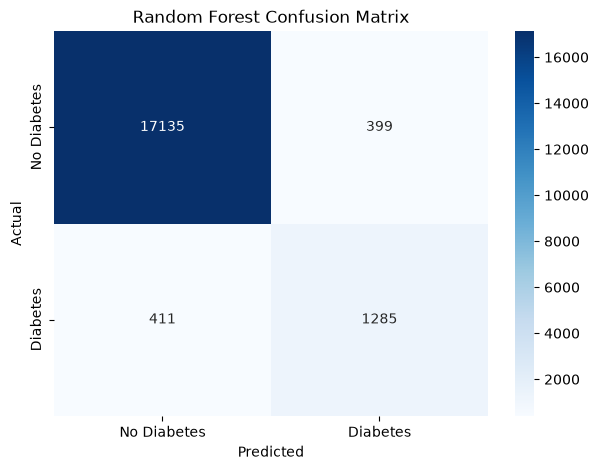

In [26]:
y_pred_rf = rf_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

## 14. Model Comparison

In [27]:
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,XGBoost,0.971451,0.977519,0.692217,0.810494,0.977890
4,Gradient Boosting,0.971971,0.989839,0.689269,0.812652,0.977362
2,Random Forest,0.957878,0.763064,0.757665,0.760355,0.965198
0,Logistic Regression,0.884451,0.425071,0.879717,0.573185,0.960068
3,KNN,0.959282,0.885232,0.618514,0.728219,0.900802
1,Decision Tree,0.952626,0.727536,0.739976,0.733704,0.856907


##### Visual comparison:

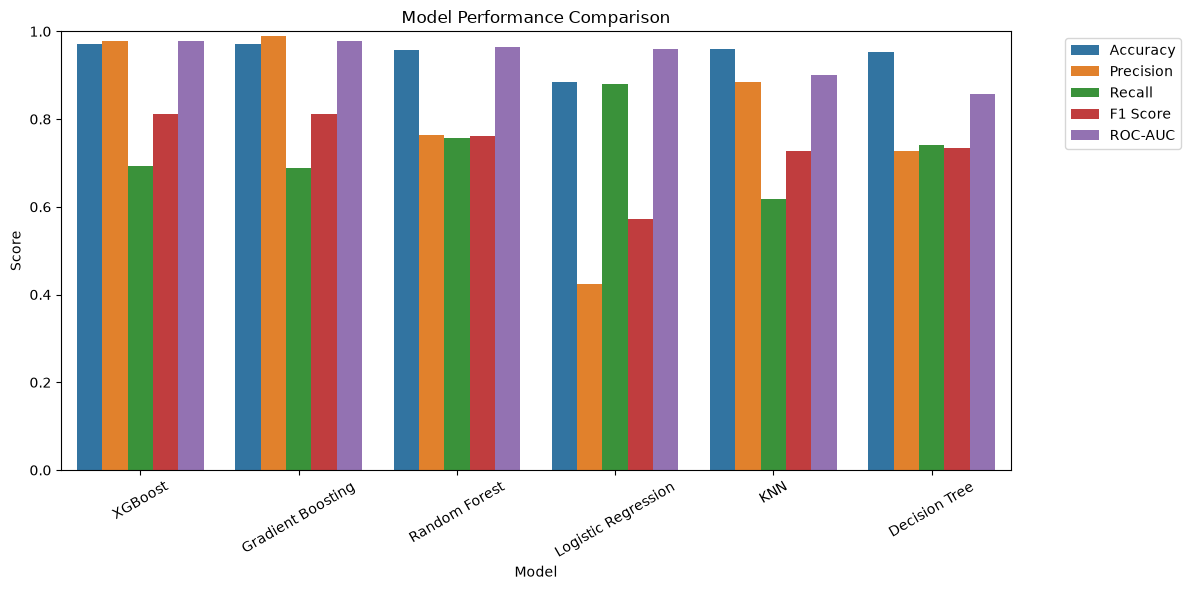

In [28]:
plt.figure(figsize=(12, 6))

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 15. ROC Curve

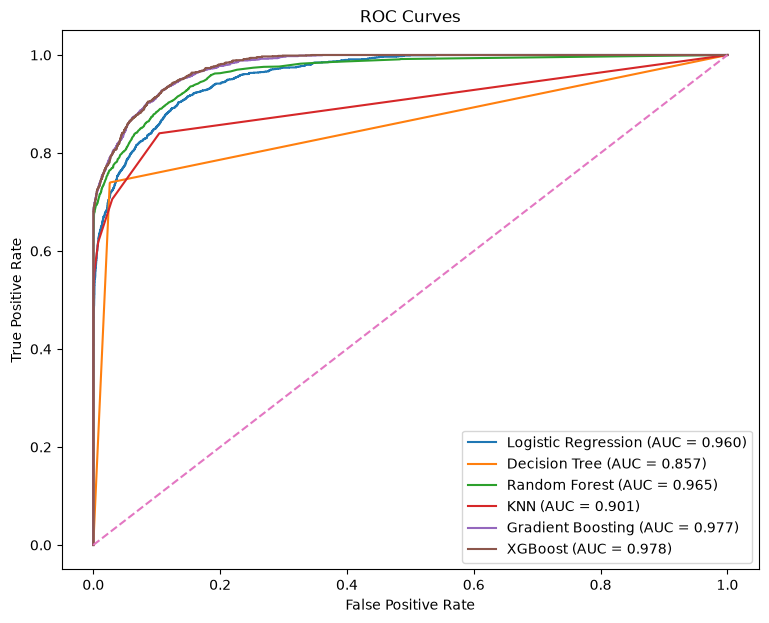

In [29]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 7))

for name, model in models.items():

    y_probability = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_probability
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.show()

## 16. Hyperparameter Tuning

tuning Random Forest and XGBoost, rather than spending huge amounts of computation tuning every model.

#### 1.Random Forest Grid Search :

In [32]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:")
print(rf_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_grid.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/opt/anaconda3/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best CV ROC-AUC:
0.9753737834714175


#### 2. XGBoost Tuning

In [33]:
xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(xgb_grid.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best XGBoost parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best CV ROC-AUC:
0.9793864604715231


## 17. Best Model Selection
Instead of manually assuming that Random Forest or XGBoost is best, compare the tuned models.

In [37]:
tuned_models = {
    "Random Forest Tuned": rf_grid.best_estimator_,
    "XGBoost Tuned": xgb_grid.best_estimator_
}
tuned_results = []

for name, model in tuned_models.items():

    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_probability)
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest Tuned,0.901872,0.470534,0.899175,0.617784,0.973364
1,XGBoost Tuned,0.971971,0.984100,0.693396,0.813559,0.978121


In [38]:
# selecting the best model based on ROC-AUC score

best_model_name = tuned_results_df.loc[
    tuned_results_df["ROC-AUC"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)
if best_model_name == "Random Forest Tuned":
    best_model = rf_grid.best_estimator_
else:
    best_model = xgb_grid.best_estimator_

print("Final model selected successfully.")

Best Model: XGBoost Tuned
Final model selected successfully.


## 18. Save Final Model

In [39]:
import joblib

MODEL_PATH = "diabetes_model.pkl"

joblib.dump(
    best_model,
    MODEL_PATH
)

print(f"Model saved successfully to {MODEL_PATH}")

Model saved successfully to diabetes_model.pkl


In [41]:
loaded_model = joblib.load("diabetes_model.pkl")

print("Saved model loaded successfully.")
sample_prediction = loaded_model.predict(X_test.iloc[:5])

sample_probability = loaded_model.predict_proba(
    X_test.iloc[:5]
)[:, 1]

print("Predictions:", sample_prediction)
print("Probabilities:", sample_probability)

Saved model loaded successfully.
Predictions: [0 0 0 0 0]
Probabilities: [1.2791426e-01 2.5549805e-06 4.5855870e-04 4.6844857e-06 7.7390840e-04]
